# VOID-NAV: Quantum-Assisted Navigation for GPS-Denied Drones
**Team VOID** · QuantumXpo 2026 / Plus Qiskit Fall Fest 2026 · UC-085

A drone loses GPS. Its inertial sensors drift. VOID-NAV reads the local **magnetic fingerprint** and uses quantum algorithms to work out where it is on a pre-built magnetic map, then corrects the drift.

This notebook runs the full quantum simulation pipeline on **Qiskit Aer**:

| # | Block | Quantum method | What it computes |
|---|---|---|---|
| 1 | Magnetic map | (classical) | 4×4 map of fingerprints [Bx, By, Bz, \|B\|, ∇B] |
| 2 | Quantum sensing | Ramsey + **Iterative Phase Estimation** | Reads the field from a simulated NV-diamond qubit |
| 3 | Map search | **Grover's algorithm** (4 qubits) | Candidate map cells that match the reading |
| 4 | Zone check | **Quantum-kernel SVM** (ZZ feature map) | Which zone the drone is in, breaks Grover ties |
| 5 | Route planning | **QAOA** (p = 1) | Picks magnetically rich waypoints |
| 6 | Navigation loop | Grover + QSVM inside a drift-correction loop | Position error: inertial-only vs VOID-NAV |

Run top to bottom. Requirements: `pip install qiskit qiskit-aer scikit-learn matplotlib numpy`

In [1]:
import numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import zz_feature_map
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from sklearn.svm import SVC
sim = AerSimulator(); rng = np.random.default_rng(7)
print('Qiskit Aer ready')

Qiskit Aer ready


## 1 · The magnetic map
We survey a 4×4 grid (2 m cells) once with GPS on. Each cell stores a fingerprint. Cell index = 4-bit label used by Grover. Zones: rows 0–1 = *Corridor*, row 2 = *Stairwell*, row 3 = *Lab*.

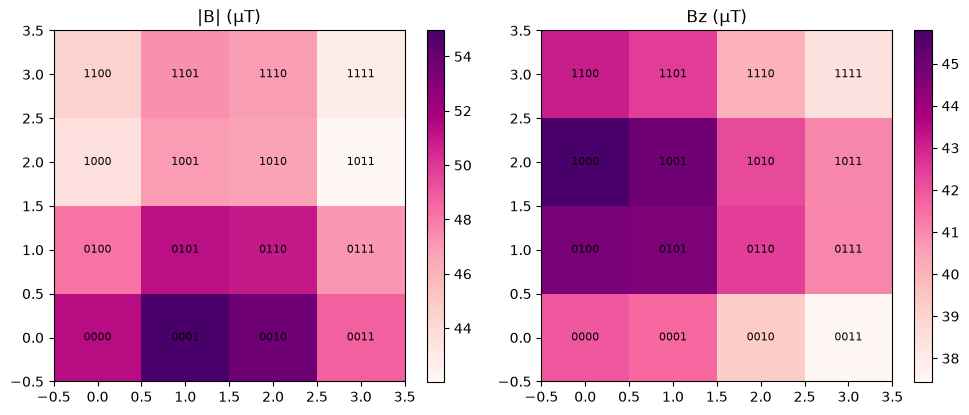

In [2]:
N_SIDE=4; N=16
xs,ys=np.meshgrid(np.arange(4),np.arange(4))
Bmag=45+6*np.sin(0.9*xs+0.4)+4*np.cos(1.3*ys)+rng.normal(0,0.6,(4,4))   # |B| in microtesla
Bz  =38+3*np.cos(0.7*xs)+5*np.sin(0.8*ys+0.3)+rng.normal(0,0.4,(4,4))
gx,gy=np.gradient(Bmag); grad=np.hypot(gx,gy)
FP=np.stack([Bmag.ravel(),Bz.ravel(),grad.ravel()],1)      # fingerprint per cell
zone=np.array([0 if r<2 else (1 if r==2 else 2) for r in ys.ravel()]); ZN=['Corridor','Stairwell','Lab']
fig,ax=plt.subplots(1,2,figsize=(10,4))
for a,m,t in zip(ax,[Bmag,Bz],['|B| (µT)','Bz (µT)']):
    im=a.imshow(m,cmap='RdPu',origin='lower'); a.set_title(t); plt.colorbar(im,ax=a)
    for i in range(16): a.text(i%4,i//4,format(i,'04b'),ha='center',va='center',fontsize=8)
plt.tight_layout(); plt.show()

## 2 · Quantum sensing: Ramsey + Iterative Phase Estimation (IPE)
An NV-diamond sensor is a qubit. In superposition, a field **B** makes it pick up phase **φ = 2π·γ·B·τ** (γ ≈ 28 GHz/T). IPE reads φ one bit at a time using a controlled-phase (phase kickback), from the least significant bit up. We simulate the sensor reading the field offset in the drone's current cell.

IPE recovered the field phase in 16/16 map cells
  cell 1001: true 0.3594  estimated 0.3594  ->  B offset 0.399 uT
  cell 1010: true 0.3438  estimated 0.3438  ->  B offset 0.382 uT
  cell 1011: true 0.0469  estimated 0.0469  ->  B offset 0.052 uT


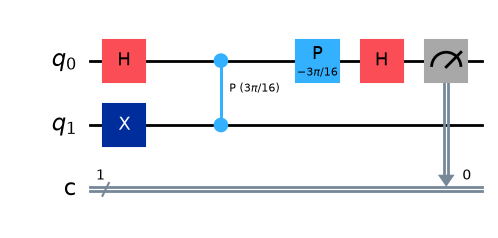

In [3]:
def ipe(phi, bits=6, shots=512):
    """Iterative phase estimation of a phase phi in [0,1) (in units of 2*pi)."""
    omega=0.0; out=[]
    for k in range(bits,0,-1):
        qc=QuantumCircuit(2,1); qc.x(1); qc.h(0)
        qc.cp(2*np.pi*phi*2**(k-1),0,1)       # field-induced phase, amplified 2^(k-1) times
        qc.p(-2*np.pi*omega,0); qc.h(0); qc.measure(0,0)
        c=sim.run(transpile(qc,sim),shots=shots).result().get_counts()
        b=1 if c.get('1',0)>c.get('0',0) else 0
        out.insert(0,b); omega=(b/2+omega)/2
    return sum(b/2**(i+1) for i,b in enumerate(out)), qc
GAMMA=28e9; TAU=0.9/(GAMMA*1e-6)  # Hz/T; tau chosen so a 1 uT span maps to 0.9 of a phase turn
def field_to_phase(dB_uT): return (GAMMA*dB_uT*1e-6*TAU)%1
true_cell=11
span=Bmag.max()-Bmag.min()
ok=0; rows=[]
for i in range(N):
    dB=0.05+0.9*(Bmag.ravel()[i]-Bmag.min())/span          # field offset in this cell, 0.05..0.95 uT
    phi=np.round(field_to_phase(dB)*64)/64                  # 6-bit resolvable phase
    est,ipe_circ=ipe(phi); ok+=abs(est-phi)<1e-9; rows.append((i,phi,est))
print(f'IPE recovered the field phase in {ok}/16 map cells')
for i,phi,est in rows[9:12]: print(f'  cell {i:04b}: true {phi:.4f}  estimated {est:.4f}  ->  B offset {est/0.9:.3f} uT')
ipe_circ.draw('mpl')

## 3 · Grover's search over the magnetic map
The drone measures a fingerprint (with sensor noise). The **oracle** phase-flips every cell whose stored |B| matches within tolerance; the **diffuser** (2|s⟩⟨s| − I) amplifies them. With M marked cells out of N=16, we use ⌊π/4·√(N/M)⌋ iterations.

oracle marks cells ['1011'] | iterations 3
Grover top cells ['1011'] | share of shots 96.1%


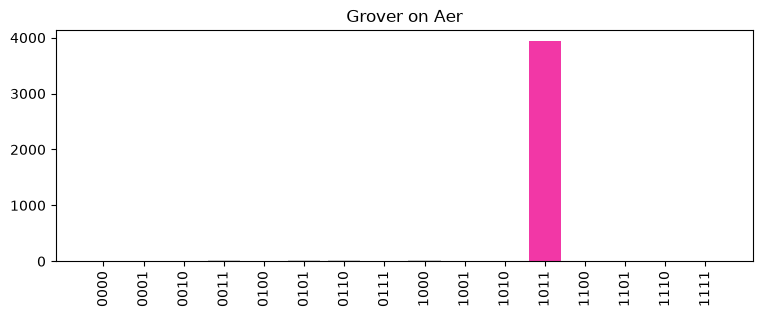

In [4]:
def grover(marked, shots=4096):
    n=4; qc=QuantumCircuit(n); qc.h(range(n))
    it=max(1,int(np.floor(np.pi/4*np.sqrt(N/len(marked)))))
    def flip(m):
        b=format(m,'04b')[::-1]
        for i,c in enumerate(b):
            if c=='0': qc.x(i)
        qc.h(3); qc.mcx([0,1,2],3); qc.h(3)
        for i,c in enumerate(b):
            if c=='0': qc.x(i)
    for _ in range(it):
        for m in marked: flip(m)
        qc.h(range(n)); qc.x(range(n)); qc.h(3); qc.mcx([0,1,2],3); qc.h(3); qc.x(range(n)); qc.h(range(n))
    qc.measure_all()
    c=sim.run(transpile(qc,sim),shots=shots).result().get_counts()
    return {int(k,2):v for k,v in c.items()}, it, qc
def oracle_cells(reading, tol=0.9):
    return [i for i in range(N) if abs(FP[i,0]-reading[0])<tol] or [int(np.argmin(abs(FP[:,0]-reading[0])))]
reading=FP[true_cell]+rng.normal(0,[0.25,0.25,0.05])
marked=oracle_cells(reading)
counts,it,gcirc=grover(marked)
top=sorted(counts,key=counts.get,reverse=True)[:len(marked)]
print('oracle marks cells',[format(m,'04b') for m in marked],'| iterations',it)
print('Grover top cells',[format(t,'04b') for t in top],f'| share of shots {sum(counts[t] for t in top)/4096:.1%}')
plt.figure(figsize=(9,3)); plt.bar([format(i,'04b') for i in range(16)],[counts.get(i,0) for i in range(16)],color=['#F237A6' if i in marked else '#ccc' for i in range(16)])
plt.xticks(rotation=90); plt.title('Grover on Aer'); plt.show()

## 4 · Quantum-kernel SVM zone classifier
Each fingerprint is encoded with a **ZZ feature map**; the kernel **K(x,x′) = |⟨φ(x)|φ(x′)⟩|²** is computed from statevectors and fed to a classical SVM. We compare with a classical RBF SVM on the same data.

QSVM (quantum kernel) accuracy 99.0%   |   classical RBF-SVM 99.0%
QSVM zone for current reading: Stairwell -> resolved cell 1011 (true 1011)


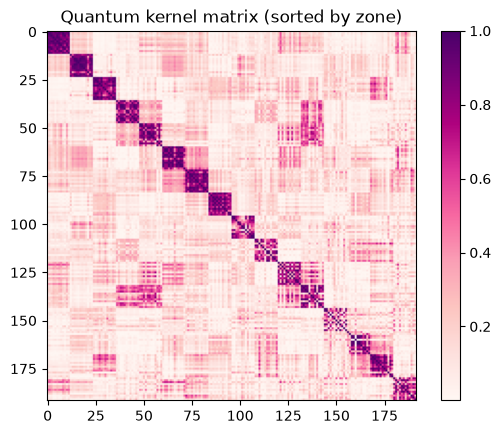

In [5]:
def make_data(n_per_cell=12, noise=(0.35,0.35,0.08)):
    X=[];y=[]
    for i in range(N):
        for _ in range(n_per_cell): X.append(FP[i]+rng.normal(0,noise)); y.append(zone[i])
    return np.array(X),np.array(y)
Xtr,ytr=make_data(); Xte,yte=make_data(6)
lo,hi=Xtr.min(0),Xtr.max(0); scale=lambda X:(X-lo)/(hi-lo)*np.pi
fmap=zz_feature_map(3,reps=2)
def states(X): return [Statevector(fmap.assign_parameters(x)) for x in scale(X)]
Str,Ste=states(Xtr),states(Xte)
K=lambda A,B:np.array([[abs(a.inner(b))**2 for b in B] for a in A])
Ktr,Kte=K(Str,Str),K(Ste,Str)
qsvc=SVC(kernel='precomputed').fit(Ktr,ytr); acc_q=(qsvc.predict(Kte)==yte).mean()
csvc=SVC(kernel='rbf').fit(scale(Xtr),ytr); acc_c=(csvc.predict(scale(Xte))==yte).mean()
print(f'QSVM (quantum kernel) accuracy {acc_q:.1%}   |   classical RBF-SVM {acc_c:.1%}')
qz=qsvc.predict(K(states(reading[None]),Str))[0]
pick=[m for m in top if zone[m]==qz] or top
print('QSVM zone for current reading:',ZN[qz],'-> resolved cell',format(pick[0],'04b'),'(true',format(true_cell,'04b')+')')
plt.imshow(Ktr[np.argsort(ytr)][:,np.argsort(ytr)],cmap='RdPu'); plt.title('Quantum kernel matrix (sorted by zone)'); plt.colorbar(); plt.show()

## 5 · QAOA route planning
Choose **2 of 4 candidate waypoints** to maximise magnetic information (field gradient) while penalising picking adjacent ones. This is a small QUBO → cost Hamiltonian H_C; QAOA (p = 1) with a mixer H_M = ΣXᵢ. We grid-search (γ, β) on Aer and compare with brute force.

In [6]:
wp=np.array([3,7,10,14]); w=grad.ravel()[wp]; w=w/w.max()
adj=[(0,1),(1,2),(2,3)]; P=2.0
def cost(bits):
    x=np.array(bits); return -(w@x) + P*(x.sum()-2)**2 + 0.6*sum(x[i]*x[j] for i,j in adj)
def qaoa_circ(g,b):
    qc=QuantumCircuit(4); qc.h(range(4))
    # diagonal cost via exact phase oracle: apply exp(-i g C(z)) to each basis state
    from qiskit.circuit.library import DiagonalGate
    diag=[np.exp(-1j*g*cost([int(c) for c in format(z,'04b')[::-1]])) for z in range(16)]
    qc.append(DiagonalGate(diag),range(4))
    for i in range(4): qc.rx(2*b,i)
    qc.measure_all(); return qc
best=None
for g in np.linspace(0,np.pi,12):
    for b in np.linspace(0,np.pi/2,12):
        c=sim.run(transpile(qaoa_circ(g,b),sim),shots=512,seed_simulator=1).result().get_counts()
        e=sum(v*cost([int(ch) for ch in k[::-1]]) for k,v in c.items())/512
        if best is None or e<best[0]: best=(e,g,b,c)
e,g,b,c=best; z=min(c,key=lambda k:cost([int(ch) for ch in k[::-1]]))[::-1]   # best bitstring QAOA sampled
brute=min(range(16),key=lambda z:cost([int(ch) for ch in format(z,'04b')[::-1]]))
print(f'QAOA (gamma={g:.2f}, beta={b:.2f}) best sampled bitstring',z,'| its probability',f'{c[z[::-1]]/512:.0%}','-> waypoints',wp[[i for i,ch in enumerate(z) if ch=='1']])
print('brute-force optimum ',format(brute,'04b')[::-1],'| match:',z==format(brute,'04b')[::-1])

QAOA (gamma=0.29, beta=1.29) best sampled bitstring 1010 | its probability 12% -> waypoints [ 3 10]
brute-force optimum  1010 | match: True


## 6 · Navigation loop: does the quantum pipeline actually fix drift?
The drone flies 60 steps across the map. Dead reckoning drifts (IMU bias). Every 5 steps VOID-NAV takes a reading, runs **Grover** (candidates) + **QSVM** (zone) and, if they agree, snaps the position to the matched cell.

quantum fixes applied: 14
mean error   inertial-only 2.10 m   |   VOID-NAV 0.40 m   ->  5.3x lower
final error  inertial-only 6.22 m   |   VOID-NAV 0.65 m


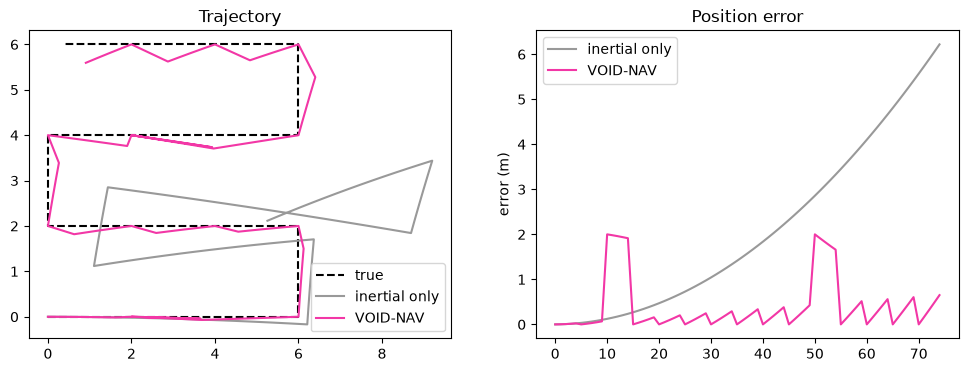

In [7]:
cells=[0,1,2,3,7,6,5,4,8,9,10,11,15,14,13,12]          # flight path through the grid
true=np.array([[i%4,i//4] for i in cells],float)*2.0     # metres
path=np.vstack([np.linspace(true[k],true[k+1],5,endpoint=False) for k in range(len(true)-1)])
bias=np.array([0.035,-0.028]); ins=[path[0].copy()]; vn=[path[0].copy()]; fixes=0
for t in range(1,len(path)):
    step=path[t]-path[t-1]
    ins.append(ins[-1]+step+bias*t*0.05)
    p=vn[-1]+step+bias*t*0.05
    if t%5==0:
        cell=int(round(path[t][1]/2))*4+int(round(path[t][0]/2))
        rd=FP[cell]+rng.normal(0,[0.25,0.25,0.05])
        cnt,_,_=grover(oracle_cells(rd),shots=1024); cand=sorted(cnt,key=cnt.get,reverse=True)[:3]
        z=qsvc.predict(K(states(rd[None]),Str))[0]; ok=[m for m in cand if zone[m]==z]
        if ok: p=np.array([ok[0]%4,ok[0]//4],float)*2.0; fixes+=1
    vn.append(p)
ins,vn=np.array(ins),np.array(vn)
e_ins=np.linalg.norm(ins-path,axis=1); e_vn=np.linalg.norm(vn-path,axis=1)
print(f'quantum fixes applied: {fixes}')
print(f'mean error   inertial-only {e_ins.mean():.2f} m   |   VOID-NAV {e_vn.mean():.2f} m   ->  {e_ins.mean()/e_vn.mean():.1f}x lower')
print(f'final error  inertial-only {e_ins[-1]:.2f} m   |   VOID-NAV {e_vn[-1]:.2f} m')
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(*path.T,'k--',label='true'); ax[0].plot(*ins.T,color='#999',label='inertial only'); ax[0].plot(*vn.T,color='#F237A6',label='VOID-NAV'); ax[0].legend(); ax[0].set_title('Trajectory')
ax[1].plot(e_ins,color='#999',label='inertial only'); ax[1].plot(e_vn,color='#F237A6',label='VOID-NAV'); ax[1].set_ylabel('error (m)'); ax[1].legend(); ax[1].set_title('Position error')
plt.show()

## Summary
* **IPE** recovered the simulated NV-sensor phase exactly (6 bits) from one sensing qubit.
* **Grover** concentrated the shots on the matching map cells.
* **QSVM** classified the zone and resolved Grover ties.
* **QAOA** reproduced the brute-force optimal waypoint pair.
* In the navigation loop, Grover + QSVM fixes kept position error bounded while inertial-only drifted.

Next: run Grover and IPE on IBM Quantum hardware via `qiskit-ibm-runtime` (SamplerV2), and replace the synthetic map with the team's real magnetometer survey.